# **AI-ML Core Mini Project — Student Performance Prediction System**
   - The Student Performance Prediction System is an AI/ML project that predicts a student's final academic grade using factors such as study time, previous grades, failures, and absences.

   - The project demonstrates a complete Machine Learning workflow, including data exploration, preprocessing, visualization, model training, prediction, and evaluation. A Linear Regression model is used to predict the final grade, with performance measured using MAE, MSE, RMSE, and R².

## **Project Objectives**

The main objectives of this project are:

- Understand and analyze a real-world student performance dataset.
- Perform data exploration and identify important features.
- Clean and prepare the data for machine learning.
- Visualize relationships between student factors and final grades.
- Train a machine learning model to predict final student performance.
- Evaluate the model using appropriate regression metrics.
- Create reusable prediction functions.
- Write unit tests for important project functions.
- Identify and fix bugs discovered during testing.
- Document the complete project using a README file.
- Demonstrate the complete end-to-end AI/ML workflow.

In [4]:
import pandas as pd

df = pd.read_csv("./data/student-mat.csv", sep=";")

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [5]:
# Check the dataset
print("Shape:", df.shape)

Shape: (395, 33)


In [6]:
df.columns.tolist()

['school',
 'sex',
 'age',
 'address',
 'famsize',
 'Pstatus',
 'Medu',
 'Fedu',
 'Mjob',
 'Fjob',
 'reason',
 'guardian',
 'traveltime',
 'studytime',
 'failures',
 'schoolsup',
 'famsup',
 'paid',
 'activities',
 'nursery',
 'higher',
 'internet',
 'romantic',
 'famrel',
 'freetime',
 'goout',
 'Dalc',
 'Walc',
 'health',
 'absences',
 'G1',
 'G2',
 'G3']

In [9]:
# select the features and target variable
features = ["studytime", "failures", "absences", "G1", "G2"]

target = "G3"

X = df[features]
y = df[target]

In [10]:
# Check missing values
df[features + [target]].isnull().sum()

studytime    0
failures     0
absences     0
G1           0
G2           0
G3           0
dtype: int64

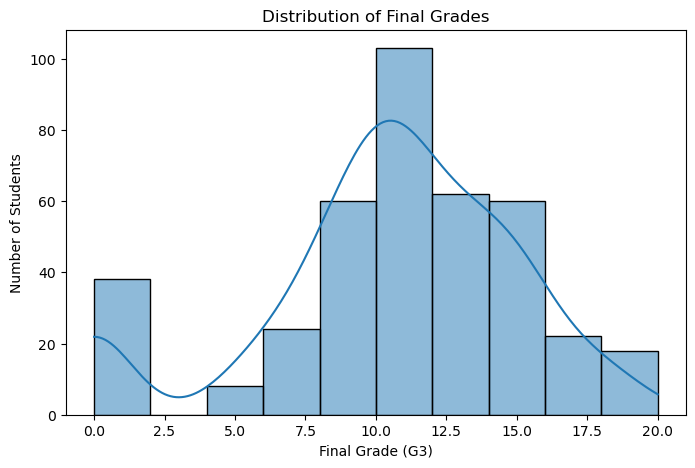

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.histplot(df["G3"], bins=10, kde=True)

plt.title("Distribution of Final Grades")
plt.xlabel("Final Grade (G3)")
plt.ylabel("Number of Students")

plt.show()

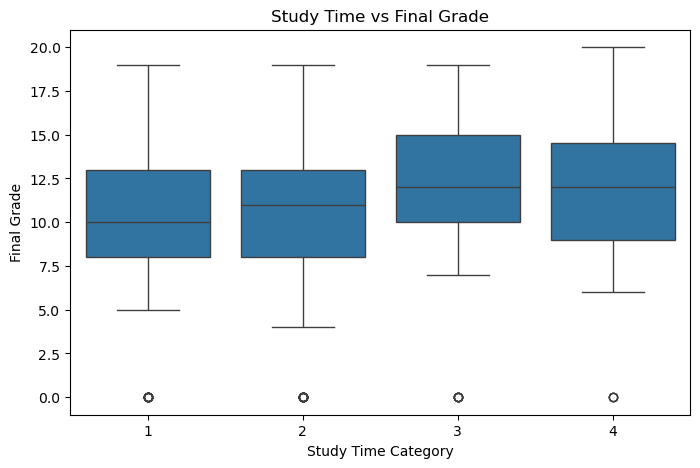

In [12]:
# Study Time vs Final Grade
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="studytime", y="G3")

plt.title("Study Time vs Final Grade")
plt.xlabel("Study Time Category")
plt.ylabel("Final Grade")
plt.show()

## Previous Grade vs Final Grade

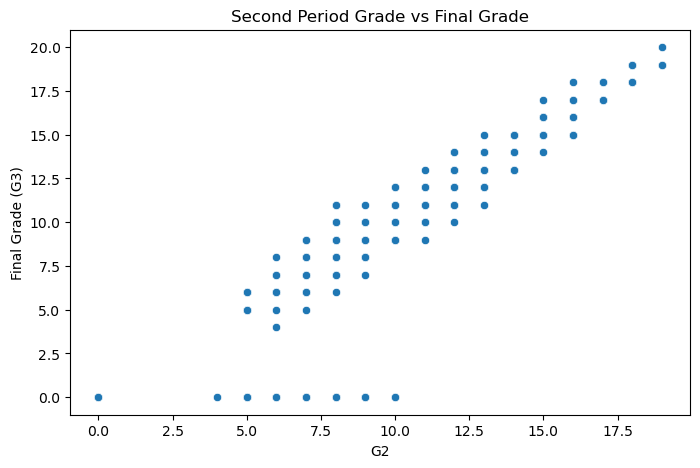

In [15]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x="G2", y="G3")

plt.title("Second Period Grade vs Final Grade")
plt.xlabel("G2")
plt.ylabel("Final Grade (G3)")
plt.show()

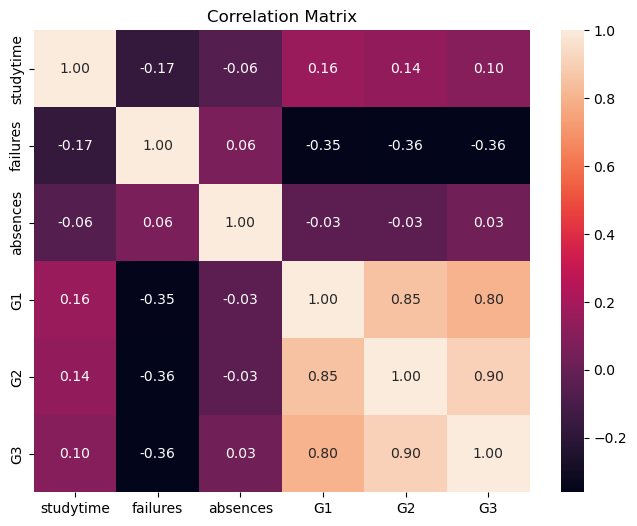

In [16]:
# Correlation Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(df[features + [target]].corr(), annot=True, fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [19]:
# Train Test split the dataset
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

# Train the model
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully!")

Training samples: 316
Testing samples: 79
Model trained successfully!


In [20]:
# Make Predictions
y_pred = model.predict(X_test)

print("Actual grades:")
print(y_test.values[:10])

print("\nPredicted grades:")
print(y_pred[:10])

Actual grades:
[10 12  5 10  9 13 18  6  0 14]

Predicted grades:
[ 6.01113762 12.20306263  3.42583945  8.52243043  7.87300271 12.70478596
 18.6925959   7.10011213  7.22885591 12.6388124 ]


In [21]:
# Evalaute the model
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("Model Evaluation")
print("-----------------")
print(f"MAE : {mae:.2f}")
print(f"MSE : {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.2f}")

Model Evaluation
-----------------
MAE : 1.34
MSE : 4.47
RMSE: 2.11
R²  : 0.78


## Actual vs Predicted Visualization

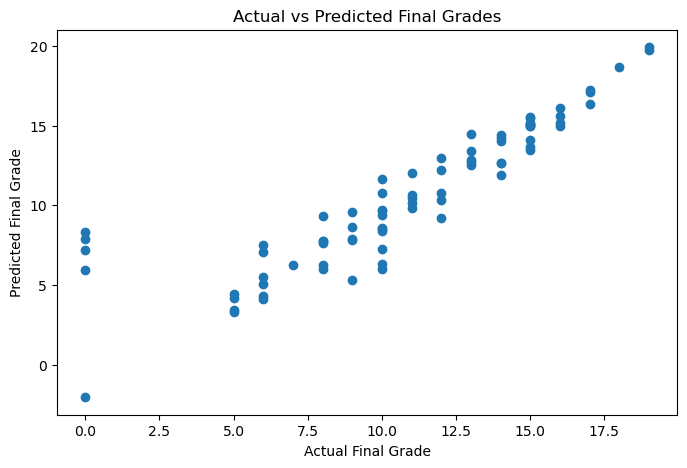

In [22]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Final Grade")
plt.ylabel("Predicted Final Grade")
plt.title("Actual vs Predicted Final Grades")
plt.show()

## Prediction Function

In [23]:
def predict_final_grade(
    model,
    studytime,
    failures,
    absences,
    G1,
    G2
):

    student = pd.DataFrame({
        "studytime": [studytime],
        "failures": [failures],
        "absences": [absences],
        "G1": [G1],
        "G2": [G2]
    })

    prediction = model.predict(student)

    return prediction[0]

## Test the Prediction

In [24]:
predicted_grade = predict_final_grade(model=model, studytime=3,
                                       failures=0, absences=5, G1=14, G2=15)

print(f"Predicted Final Grade: {predicted_grade:.2f}")

Predicted Final Grade: 15.08


In [26]:
# Categorize on the basis of performance
def grade_category(grade):

    if grade >= 16:
        return "Excellent"

    elif grade >= 14:
        return "Very Good"

    elif grade >= 12:
        return "Good"

    elif grade >= 10:
        return "Pass"

    else:
        return "Needs Improvement"

category = grade_category(predicted_grade)

print(f"Predicted Grade: {predicted_grade:.2f}")
print(f"Performance: {category}")

Predicted Grade: 15.08
Performance: Very Good


## User Prediction

In [29]:
def student_prediction(
    studytime,
    failures,
    absences,
    G1,
    G2
):

    predicted_grade = predict_final_grade(
        model=model,
        studytime=studytime,
        failures=failures,
        absences=absences,
        G1=G1,
        G2=G2
    )

    category = grade_category(
        predicted_grade
    )

    return predicted_grade, category

grade, category = student_prediction(
    studytime=3,
    failures=0,
    absences=5,
    G1=14,
    G2=15
)

print("Student Prediction")
print("------------------")
print(f"Predicted Final Grade: {grade:.2f}")
print(f"Performance Category: {category}")

Student Prediction
------------------
Predicted Final Grade: 15.08
Performance Category: Very Good


## Final Project Output

### Model Evaluation
- MAE: 1.34
- MSE: 4.47
- RMSE: 2.11
- R²: 0.78

### Final Prediction
- Predicted Final Grade: 15.08
- Performance Category: Very Good

This project shows that the regression model is able to predict student final grades with a reasonably good accuracy and classify the performance as "Very Good" for the given sample input.